# 2D Ising Model — Monte Carlo Simulation
**Metropolis Algorithm** | Figure 8.8 translation

The Ising model is one of the most important models in statistical physics. It represents a ferromagnet as a 2D grid of magnetic dipoles ("spins"), each of which can point either **up** (+1) or **down** (−1). Despite its simplicity, it captures the essential physics of phase transitions — including the spontaneous emergence of magnetisation below a critical temperature $T_c$.

This notebook simulates the model using the **Metropolis Monte Carlo algorithm**, which samples spin configurations according to the Boltzmann distribution of statistical mechanics.

---
## Cell 1 — Imports & Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display

# ── Parameters ────────────────────────────────────────────────────────────────
SIZE = 10          # Width of square lattice
T    = 2.5         # Temperature in units of ε/k  (T_c ≈ 2.269)
N_STEPS = 100 * SIZE**2   # Total Monte Carlo steps

### 📐 Physics: Setting the Scale

The two key physical parameters are:

- **`SIZE = 10`** — the lattice is a 10×10 grid of 100 spins. In a real ferromagnet this would be on the order of $10^{23}$ atoms; we use a small lattice to make the simulation tractable.

- **`T = 2.5`** — temperature measured in units of $\varepsilon/k_B$, where $\varepsilon$ is the spin-coupling energy and $k_B$ is Boltzmann's constant. This is a *dimensionless* temperature that makes the physics unit-independent. The exact critical temperature for an infinite 2D lattice is the Onsager result:

$$T_c = \frac{2}{\ln(1+\sqrt{2})} \approx 2.269 \quad (\text{in units of } \varepsilon/k_B)$$

Setting $T = 2.5 > T_c$ places us in the **paramagnetic phase** — spins are thermally disordered. Try `T = 1.5` to see the ordered, ferromagnetic phase.

- **`N_STEPS = 100 × N`** — each "Monte Carlo step" attempts one spin flip per lattice site on average. Running $100 \times N$ total attempts ($N = $ `SIZE`²) gives the lattice roughly 100 full sweeps to approach thermal equilibrium.

---
## Cell 2 — Core Physics Functions

In [2]:
# ── Initialisation ─────────────────────────────────────────────────────────────
def initialize(size):
    """Random ±1 spin lattice."""
    return np.where(np.random.rand(size, size) < 0.5, 1, -1)


# ── Energy of a hypothetical flip ─────────────────────────────────────────────
def delta_U(s, i, j):
    """
    Change in energy if spin s[i,j] is flipped.
    Uses periodic boundary conditions (modulo indexing).
    """
    size = s.shape[0]
    top    = s[(i - 1) % size, j]
    bottom = s[(i + 1) % size, j]
    left   = s[i, (j - 1) % size]
    right  = s[i, (j + 1) % size]
    return 2 * s[i, j] * (top + bottom + left + right)


# ── One Metropolis sweep ───────────────────────────────────────────────────────
def metropolis_sweep(s, T):
    """Attempt SIZE² single-spin flips (one Monte Carlo step)."""
    size = s.shape[0]
    for _ in range(size * size):
        i = np.random.randint(size)
        j = np.random.randint(size)
        Ediff = delta_U(s, i, j)
        if Ediff <= 0 or np.random.rand() < np.exp(-Ediff / T):
            s[i, j] = -s[i, j]
    return s


# ── Observables ───────────────────────────────────────────────────────────────
def total_energy(s):
    """Total energy per spin (J = 1)."""
    size = s.shape[0]
    E = -np.sum(
        s * (np.roll(s, 1, axis=0) + np.roll(s, 1, axis=1))
    )
    return E / size**2


def magnetisation(s):
    """Mean magnetisation per spin."""
    return np.mean(s)

### ⚛️ Physics: The Hamiltonian, Energy Change, and Metropolis Rule

#### The Ising Hamiltonian

The total energy of the system is given by the **Ising Hamiltonian**:

$$H = -J \sum_{\langle i,j \rangle} s_i s_j$$

where $\langle i,j \rangle$ denotes a sum over **nearest-neighbour pairs**, $s_i = \pm 1$ is the spin at site $i$, and $J > 0$ is the coupling constant (set to 1 here). The minus sign means **aligned neighbours** ($s_i s_j = +1$) **lower** the energy — this is the origin of ferromagnetism.

---

#### `initialize(size)` — infinite-temperature starting state

Each spin is set randomly to +1 or −1 with equal probability. This corresponds to an **infinite-temperature** configuration — maximum disorder, zero net magnetisation. Starting here is unbiased and lets the simulation evolve toward whatever equilibrium state $T$ demands.

---

#### `delta_U(s, i, j)` — the energy cost of a flip

Rather than recomputing $H$ for the whole lattice after every proposed flip, we exploit the fact that flipping spin $s_{ij}$ only changes its four nearest-neighbour interactions. The energy change is:

$$\Delta U = 2 \, s_{ij} \sum_{\text{nn}} s_{\text{nn}}$$

The factor of 2 arises because flipping $s_{ij} \to -s_{ij}$ reverses the sign of all four bond energies — effectively doubling the change. The `% size` modulo operator implements **periodic boundary conditions**: the right edge wraps to the left, and the top to the bottom, eliminating surface effects and approximating an infinite lattice.

---

#### `metropolis_sweep(s, T)` — the Metropolis acceptance rule

The Metropolis algorithm samples spin configurations from the **Boltzmann distribution**:

$$P(\text{config}) \propto e^{-H/k_B T}$$

It does this by proposing random flips and accepting or rejecting them with probability:

$$P_{\text{accept}} = \min\!\left(1,\; e^{-\Delta U / k_B T}\right)$$

In code:
- **If `Ediff ≤ 0`** — the flip lowers the energy, so it is *always* accepted. The system naturally rolls downhill toward lower-energy configurations.
- **If `Ediff > 0`** — the flip raises the energy, but it is still accepted with probability $e^{-\Delta U/T}$. This allows the system to escape local minima and correctly samples **thermal fluctuations**. At high $T$, even costly flips are frequently accepted; at low $T$, the lattice freezes into an ordered state.

This rule satisfies **detailed balance**, which guarantees that after many sweeps the system converges to the true thermal equilibrium distribution.

---

#### `total_energy(s)` and `magnetisation(s)` — macroscopic observables

`total_energy` evaluates the Hamiltonian using `np.roll` to shift the lattice by one site and sum all nearest-neighbour products simultaneously — a vectorised equivalent of the double sum in $H$. The result is normalised per spin.

`magnetisation` is simply $\langle M \rangle = \frac{1}{N}\sum_i s_i$ — the mean spin. In the **ferromagnetic phase** ($T < T_c$), this is nonzero (all spins tend to align). In the **paramagnetic phase** ($T > T_c$), it fluctuates around zero.

---
## Cell 3 — Run the Simulation

In [3]:
# ── Run simulation ─────────────────────────────────────────────────────────────
np.random.seed(42)
s = initialize(SIZE)

n_sweeps = 100          # total sweeps  (each sweep = SIZE² attempted flips)
snapshots = []          # lattice snapshots for animation
energies  = []
mags      = []

for sweep in range(n_sweeps):
    s = metropolis_sweep(s, T)
    energies.append(total_energy(s))
    mags.append(magnetisation(s))
    if sweep % 5 == 0:            # save every 5th frame
        snapshots.append(s.copy())

print(f"Final  <E>/spin = {energies[-1]:.4f}")
print(f"Final  <M>/spin = {mags[-1]:.4f}")

Final  <E>/spin = -1.1200
Final  <M>/spin = -0.7400


### 🔄 Physics: Equilibration and Thermal Averages

Each call to `metropolis_sweep` attempts `SIZE²` = 100 individual spin flips, so one sweep gives every spin *on average* one chance to flip. Running 100 sweeps means each spin has had ~100 opportunities to update — this is usually enough for a small lattice to reach **thermal equilibrium**.

**What equilibration looks like physically:**  
Starting from a random configuration (infinite-temperature state), the system is initially far from the equilibrium distribution at temperature $T$. During the first tens of sweeps, the energy drops rapidly as the Metropolis rule preferentially accepts energy-lowering flips. Eventually the energy fluctuates around a stable mean — the system has thermalised.

**Why we save snapshots every 5 sweeps:**  
Consecutive sweeps are **correlated** — each configuration differs from the previous by only a handful of flips. Saving every 5th frame gives more visually distinct snapshots and, for longer production runs, reduces autocorrelation in statistical measurements.

**Interpreting the printed output:**  
- At $T = 2.5 > T_c$: expect $\langle E \rangle/N \approx -1$ to $-0.5$ (partial order), $\langle M \rangle/N \approx 0$ (no net alignment).
- At $T = 1.5 < T_c$: expect $\langle E \rangle/N \approx -1.7$ to $-1.9$ (strongly ordered), $|\langle M \rangle/N| \approx 0.9$ (nearly all spins aligned).

---
## Cell 4 — Static Visualisation

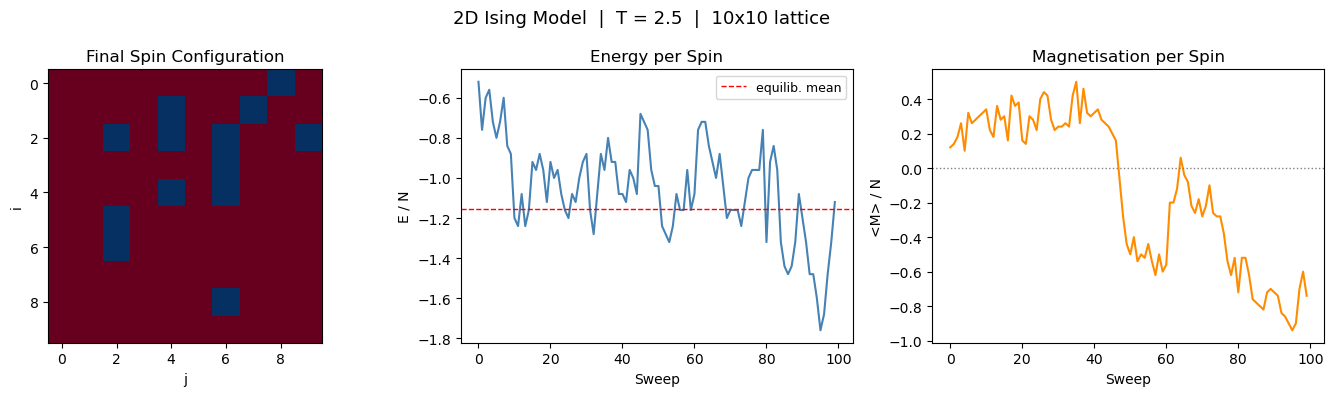

In [4]:
# ── Static visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'2D Ising Model  |  T = {T}  |  {SIZE}x{SIZE} lattice', fontsize=13)

# Final spin configuration
axes[0].imshow(s, cmap='RdBu', vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_title('Final Spin Configuration')
axes[0].set_xlabel('j'); axes[0].set_ylabel('i')

# Energy vs sweep
axes[1].plot(energies, color='steelblue', lw=1.5)
axes[1].set_title('Energy per Spin')
axes[1].set_xlabel('Sweep'); axes[1].set_ylabel('E / N')
axes[1].axhline(np.mean(energies[n_sweeps//2:]), color='red',
                ls='--', lw=1, label='equilib. mean')
axes[1].legend(fontsize=9)

# Magnetisation vs sweep
axes[2].plot(mags, color='darkorange', lw=1.5)
axes[2].set_title('Magnetisation per Spin')
axes[2].set_xlabel('Sweep'); axes[2].set_ylabel('<M> / N')
axes[2].axhline(0, color='grey', ls=':', lw=1)

plt.tight_layout()
plt.show()

### 📊 Physics: Reading the Plots

**Left — Spin configuration heatmap:**  
Red squares = spin up (+1), blue squares = spin down (−1). At $T > T_c$, you should see a roughly equal mixture of red and blue with no large coherent domains — the system is **disordered** (paramagnetic). At $T < T_c$, one colour dominates across large connected regions, signalling **spontaneous symmetry breaking**: the system has chosen one of the two equivalent ground states (all-up or all-down) by chance.

**Middle — Energy per spin vs. sweep:**  
The steep drop at the start is the **equilibration transient** — the system releasing excess energy from its random initial state. Once it levels off into noisy fluctuations around the red dashed line, the system has reached thermal equilibrium. The fluctuations themselves are physical: they correspond to **thermal fluctuations** in energy, whose variance is proportional to the heat capacity:

$$C_V = \frac{\langle (\Delta E)^2 \rangle}{k_B T^2}$$

**Right — Magnetisation per spin vs. sweep:**  
At $T > T_c$, $\langle M \rangle$ wanders randomly around zero — there is no preferred direction for alignment. At $T < T_c$, the curve drifts away from zero and stabilises near $\pm 1$, demonstrating **ferromagnetic order**. The sign chosen is random (another manifestation of spontaneous symmetry breaking).

---
## Cell 5 — Animation of Lattice Evolution

In [5]:
# ── Animation ─────────────────────────────────────────────────────────────────
fig_anim, ax_anim = plt.subplots(figsize=(4, 4))
im = ax_anim.imshow(snapshots[0], cmap='RdBu', vmin=-1, vmax=1,
                    interpolation='nearest')
ax_anim.set_title('Spin lattice evolution')
title_txt = ax_anim.set_xlabel('sweep 0')

def update(frame):
    im.set_data(snapshots[frame])
    ax_anim.set_xlabel(f'sweep {frame * 5}')
    return [im]

ani = animation.FuncAnimation(
    fig_anim, update, frames=len(snapshots),
    interval=150, blit=True
)
plt.close(fig_anim)   # prevent duplicate static display

from IPython.display import HTML
HTML(ani.to_jshtml())

### 🎬 Physics: Watching the System Thermalise

The animation shows the lattice every 5 sweeps, making the time evolution of the spin system directly visible.

**What to look for:**

- **Early frames (sweeps 0–20):** The lattice starts maximally disordered. You can watch **spin domains** — patches of aligned spins — nucleate and grow as the Metropolis rule begins preferentially accepting energy-lowering flips. This is the non-equilibrium relaxation toward the Boltzmann distribution.

- **Later frames (sweeps 20–100):** The domain structure fluctuates but no longer systematically grows. The system is at equilibrium: domain creation and destruction are balanced by **thermal fluctuations**. The characteristic domain size is set by the **correlation length** $\xi$, which diverges as $T \to T_c$:

$$\xi \sim |T - T_c|^{-\nu}, \quad \nu = 1 \quad (\text{2D Ising})$$

Near $T_c$, domains grow to span the entire lattice — this is a **critical fluctuation**, the microscopic signature of the phase transition.

- **At $T < T_c$:** The animation will show the lattice quickly locking into a predominantly red or blue state, with only small thermally-activated domain walls remaining.

---
## Cell 6 — Phase Transition: Temperature Sweep

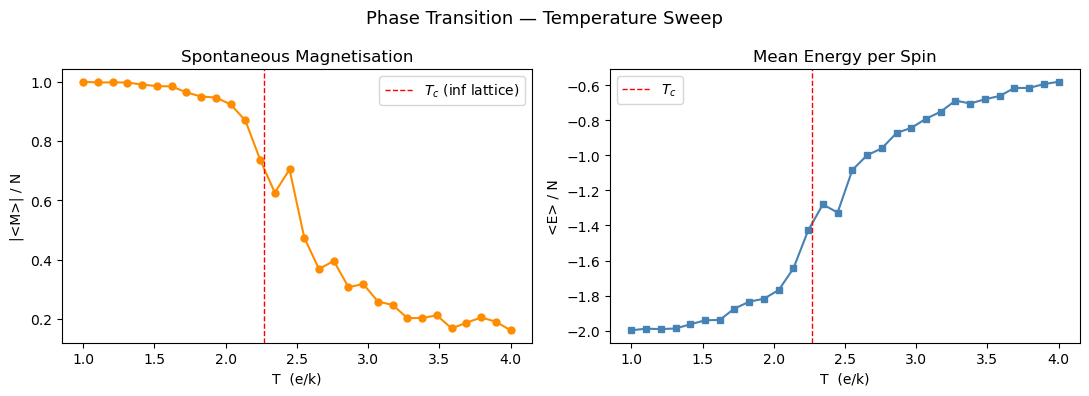

In [6]:
# ── Temperature sweep — phase transition ──────────────────────────────────────
# Sweep T from 1.0 to 4.0 and measure equilibrium |M| and E

temps      = np.linspace(1.0, 4.0, 30)
eq_mag     = []
eq_energy  = []

N_EQ   = 200   # equilibration sweeps
N_MEAS = 100   # measurement sweeps

for Tval in temps:
    s_t = initialize(SIZE)
    for _ in range(N_EQ):
        s_t = metropolis_sweep(s_t, Tval)
    m_acc, e_acc = [], []
    for _ in range(N_MEAS):
        s_t = metropolis_sweep(s_t, Tval)
        m_acc.append(abs(magnetisation(s_t)))
        e_acc.append(total_energy(s_t))
    eq_mag.append(np.mean(m_acc))
    eq_energy.append(np.mean(e_acc))

fig2, (ax_m, ax_e) = plt.subplots(1, 2, figsize=(11, 4))
fig2.suptitle('Phase Transition — Temperature Sweep', fontsize=13)

ax_m.plot(temps, eq_mag, 'o-', color='darkorange', ms=5)
ax_m.axvline(2.269, color='red', ls='--', lw=1, label='$T_c$ (inf lattice)')
ax_m.set_xlabel('T  (e/k)'); ax_m.set_ylabel('|<M>| / N')
ax_m.set_title('Spontaneous Magnetisation')
ax_m.legend()

ax_e.plot(temps, eq_energy, 's-', color='steelblue', ms=5)
ax_e.axvline(2.269, color='red', ls='--', lw=1, label='$T_c$')
ax_e.set_xlabel('T  (e/k)'); ax_e.set_ylabel('<E> / N')
ax_e.set_title('Mean Energy per Spin')
ax_e.legend()

plt.tight_layout()
plt.show()

### 🌡️ Physics: The Ferromagnetic Phase Transition

This cell measures the two key observables across a range of temperatures to map out the **phase diagram** of the Ising model.

**Why re-initialise at each temperature?**  
Each temperature is an independent simulation starting from a fresh random state. The 200-sweep equilibration period (`N_EQ`) lets the system forget its initial conditions before the 100-sweep measurement window (`N_MEAS`) records averages. Using `abs(magnetisation)` removes the sign ambiguity — since the two ground states (all-up / all-down) are equivalent, we only care about the *magnitude* of order.

---

**Left plot — Spontaneous magnetisation $|\langle M \rangle|$:**

This is the **order parameter** of the phase transition. Onsager's exact solution for an infinite lattice predicts:

$$|\langle M \rangle| = \begin{cases} \left(1 - \sinh^{-4}(2/T)\right)^{1/8} & T < T_c \\ 0 & T \geq T_c \end{cases}$$

- For $T \ll T_c$: spins are strongly aligned, so $|\langle M \rangle| \approx 1$ — **ferromagnetic phase**
- At $T = T_c$: the magnetisation drops to zero via a **continuous (second-order) phase transition**
- For $T > T_c$: thermal fluctuations dominate, so $|\langle M \rangle| \approx 0$ — **paramagnetic phase**

On a small 10×10 lattice, the transition will be **rounded and shifted** slightly from $T_c = 2.269$ — this is a **finite-size effect**. Larger lattices (try `SIZE = 50`) sharpen the transition dramatically.

**Right plot — Mean energy per spin $\langle E \rangle$:**

The energy changes smoothly from $\approx -2$ at low $T$ (all spins aligned, all bonds satisfied) toward $0$ at high $T$ (random spins, equal numbers of aligned and anti-aligned bonds). The slope $d\langle E \rangle/dT$ is proportional to the **specific heat** $C_V$, which peaks sharply at $T_c$ — another hallmark of the second-order transition. On a finite lattice this peak is finite; it diverges logarithmically as $N \to \infty$:

$$C_V \sim -\ln|T - T_c| \quad \text{(2D Ising, exact result)}$$

---

**Summary of the phase diagram:**

| Region | $T$ | $|\langle M \rangle|$ | $\langle E \rangle$ | Description |
|--------|-----|----------------------|---------------------|-------------|
| Ferromagnetic | $T < 2.27$ | $\sim 1$ | $\sim -2$ | Long-range order, large domains |
| Critical point | $T = T_c$ | $\to 0$ | $\approx -1.45$ | Scale-invariant fluctuations, power-law correlations |
| Paramagnetic | $T > 2.27$ | $\approx 0$ | $\to 0$ | Disordered, short-range correlations only |